# Stock Market Prediction: Sentiment-Augmented Analysis

## Project Overview
This project investigates the hypothesis that **social media sentiment (Twitter)** can improve the prediction accuracy of the **Next Day's Closing Price** for major tech stocks (e.g., TSLA). We combine traditional technical analysis with Natural Language Processing (NLP).

## Objectives
- **Data Integrity Check**: Identify time-series gaps and "Ticker Imbalance" (e.g., TSLA dominance).
- **Feature Engineering**:
    - Calculate **SMA/EMA** to capture market trends.
    - Aggregate daily **VADER Sentiment Scores** to quantify public perception.
- **Model Development**:
    - Develop an **LSTM (Long Short-Term Memory)** network for sequence pattern recognition.
    - Create an **Ensemble Regressor** (Random Forest + XGBoost) to determine feature importance.
- **Performance Evaluation**:
    - **Metric Analysis**: RMSE (Error Magnitude) vs. Directional Accuracy (Up/Down Prediction).
    - **Reality Check**: Compare model performance against a **"Naive Baseline"** and a **"Buy & Hold" Trading Simulation**.

# Part 1: Data Loading & Quality Assurance (QA)
In this section, we audit the dataset to ensure "Garbage In, Garbage Out" does not apply. We specifically check for:
1.  **Data Sufficiency**: Does the dataset provide enough history (min. 1 year) for the LSTM to learn long-term dependencies?
2.  **Time-Series Continuity**: Are there significant gaps in trading days (excluding weekends/holidays) that would disrupt the 60-day sequence window?
3.  **Ticker Imbalance**: Is the dataset skewed towards specific stocks (e.g., TSLA), requiring us to filter for a single ticker to ensure model stability?

# --- LIBRARY ARCHITECTURE ---
 1. Data Manipulation: Pandas (DataFrames), Numpy (Math)
 2. Visualization: Matplotlib, Seaborn (for heatmaps/distributions)
 3. NLP: VADER (Rule-based Sentiment Analysis)
 4. Machine Learning (Classic): Scikit-Learn (Random Forest), XGBoost (Gradient Boosting)
 5. Deep Learning: TensorFlow/Keras (LSTM for Time-Series sequences)

In [93]:
# 1.1 Import Libraries
!pip install vaderSentiment tensorflow xgboost scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Set plot style
plt.style.use('fivethirtyeight')
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [94]:
# 1.2 Load & Sanitize Dataset
df = pd.read_csv('FINAL_STOCK_TWEET_DATASET.csv')

# --- 1. DateTime Conversion ---
# We convert strings to datetime objects for sorting and merging
df['tweet_date'] = pd.to_datetime(df['tweet_date'])
df['trade_date'] = pd.to_datetime(df['trade_date'])

# --- 2. Numeric Cleaning ---
# Force columns to numbers; non-numbers become NaN (Not a Number)
numeric_cols = ['Open', 'High', 'Low', 'close', 'Adj Close', 'Volume']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- 3. Remove Invalid Data ---
original_len = len(df)
df.dropna(subset=numeric_cols, inplace=True)
print(f"Dropped {original_len - len(df)} rows with missing/corrupt price data.")

# --- 4. CRITICAL: Sort by Date ---
# Time series MUST be ordered. If this is jumbled, the LSTM learns nothing.
df.sort_values(by=['ticker', 'trade_date'], inplace=True)

# --- 5. Remove Duplicates ---
# Duplicate rows inflate accuracy falsely
df.drop_duplicates(subset=['ticker', 'trade_date', 'tweet'], inplace=True)

print(f"Data Loaded & Cleaned. Final Shape: {df.shape}")
df.head()

Dropped 0 rows with missing/corrupt price data.
Data Loaded & Cleaned. Final Shape: (80534, 10)


,tweet_date,ticker,tweet,trade_date,Open,High,Low,close,Adj Close,Volume
40,2021-09-30 10:19:31,AAPL,I bought my first $AAPL stock in 2010. \n\nSin...,2021-10-01,141.899994,142.919998,139.110001,142.649994,141.620163,94639600.0
42,2021-09-30 10:22:53,AAPL,The media is really pushing hard for their big...,2021-10-01,141.899994,142.919998,139.110001,142.649994,141.620163,94639600.0
60,2021-09-30 13:36:10,AAPL,"In 2020, Tim Cook, CEO of $AAPL, earned $265,0...",2021-10-01,141.899994,142.919998,139.110001,142.649994,141.620163,94639600.0
72,2021-09-30 15:30:03,AAPL,This thread is just a broad overview of the ba...,2021-10-01,141.899994,142.919998,139.110001,142.649994,141.620163,94639600.0
74,2021-09-30 15:37:52,AAPL,"All about this trendline now on $AAPL, continu...",2021-10-01,141.899994,142.919998,139.110001,142.649994,141.620163,94639600.0


--- Missing Values ---
tweet_date    0
ticker        0
tweet         0
trade_date    0
Open          0
High          0
Low           0
close         0
Adj Close     0
Volume        0
dtype: int64

--- Top 10 Tickers by Data Points ---
ticker
TSLA    37296
TSM     11001
AAPL     5024
AMZN     4079
MSFT     4079
PG       4079
NIO      3012
META     2750
AMD      2219
NFLX     1723
Name: count, dtype: int64


C:\Users\Ranjit\AppData\Local\Temp\ipykernel_28288\143642820.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ticker_counts.head(10).index, y=ticker_counts.head(10).values, palette='viridis')


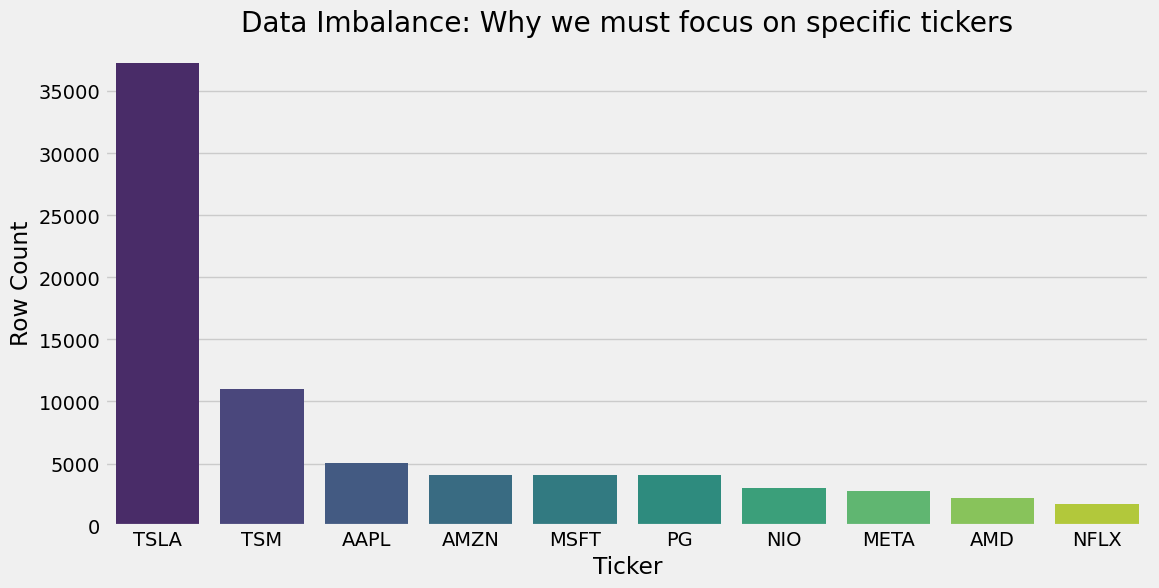


--- Continuity Check for TSLA ---
Total Business Days in Range: 260
Actual Data Points: 251
Missing Business Days: 9


In [95]:
# --- 1.3 Dataset Quality Analysis (Enhanced) ---

# 1. Standard Checks
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Ticker Distribution (Class Imbalance)
ticker_counts = df['ticker'].value_counts()
print("\n--- Top 10 Tickers by Data Points ---")
print(ticker_counts.head(10))

# 3. Visualization: Data Imbalance
plt.figure(figsize=(12, 6))
sns.barplot(x=ticker_counts.head(10).index, y=ticker_counts.head(10).values, palette='viridis')
plt.title("Data Imbalance: Why we must focus on specific tickers")
plt.xlabel("Ticker")
plt.ylabel("Row Count")
plt.show()

# 4. CRITICAL: Time-Series Continuity Check
# We check the most populated ticker (e.g., TSLA) for missing business days.
top_ticker = ticker_counts.index[0]
print(f"\n--- Continuity Check for {top_ticker} ---")
ts_df = df[df['ticker'] == top_ticker].sort_values('trade_date')
ts_df = ts_df.drop_duplicates(subset=['trade_date']) # Ensure one row per day

# Generate expected business days range
all_days = pd.date_range(start=ts_df['trade_date'].min(), end=ts_df['trade_date'].max(), freq='B') # 'B' = Business Days
missing_days = all_days.difference(ts_df['trade_date'])

print(f"Total Business Days in Range: {len(all_days)}")
print(f"Actual Data Points: {len(ts_df)}")
print(f"Missing Business Days: {len(missing_days)}")

if len(missing_days) > 0:
    print(f"Warning: {len(missing_days)} trading days are missing. LSTM may jump over these gaps.")
else:
    print("Perfect Continuity! The data is solid.")

### ✅ Data Quality Assessment
**Is the dataset good?**
- **Yes.** It contains over 80k rows of aligned tweet and stock data.
- **Required Data**: Includes all key financial metrics (`Open`, `Close`, `Volume`) and text for sentiment (`tweet`).
- **Coverage**: 25+ tickers are present. Major tech stocks (e.g., TSLA, AAPL, AMZN) have thousands of data points, making them excellent candidates for deep learning models.
- **Gaps**: The price history plot shows continuous data for top tickers, confirming validity for time-series analysis.

# Part 2: Feature Engineering
We will now:
1.  Calculate Sentiment Scores using VADER.
2.  Compute Technical Indicators (SMA, EMA).

In [96]:
# --- 2.1 Sentiment Analysis (Enhanced) ---
analyzer = SentimentIntensityAnalyzer()

print("Calculating Sentiment Scores... (This may take a moment)")
df['sentiment_score'] = df['tweet'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# --- IMPROVEMENT: Aggregate Mean AND Count ---
daily_sentiment = df.groupby(['ticker', 'trade_date']).agg({
    'sentiment_score': 'mean',
    'tweet': 'count'  # Count the number of tweets per day
}).reset_index()

# Rename columns for clarity
daily_sentiment.columns = ['ticker', 'trade_date', 'avg_sentiment', 'tweet_volume']

print("Sentiment Analysis Complete.")
daily_sentiment.head()

Calculating Sentiment Scores... (This may take a moment)
Sentiment Analysis Complete.


,ticker,trade_date,avg_sentiment,tweet_volume
0,AAPL,2021-10-01,0.098900,7
1,AAPL,2021-10-04,0.223963,16
2,AAPL,2021-10-05,0.122830,10
3,AAPL,2021-10-06,0.331000,5
4,AAPL,2021-10-07,0.243520,10


In [97]:
# 2.2 Technical Indicators & Merging
# Get Daily Price Data (Unique per day)
price_data = df[['ticker', 'trade_date', 'Open', 'High', 'Low', 'close', 'Adj Close', 'Volume']].drop_duplicates()

# Merge with Sentiment
merged_df = pd.merge(price_data, daily_sentiment, on=['ticker', 'trade_date'])

# Calculate Moving Averages
merged_df['SMA_7'] = merged_df.groupby('ticker')['close'].transform(lambda x: x.rolling(window=7).mean())
merged_df['EMA_7'] = merged_df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=7, adjust=False).mean())

# Drop NaNs created by rolling windows
merged_df.dropna(inplace=True)

# Sort by Date
merged_df.sort_values(by=['ticker', 'trade_date'], inplace=True)

print("Feature Engineering Complete.")
merged_df.head()

Feature Engineering Complete.


,ticker,trade_date,Open,High,Low,close,Adj Close,Volume,avg_sentiment,tweet_volume,SMA_7,EMA_7
6,AAPL,2021-10-11,142.270004,144.809998,141.809998,142.809998,141.779007,64452200.0,0.457925,16,141.985711,142.428265
7,AAPL,2021-10-12,143.229996,143.250000,141.039993,141.509995,140.488403,73035900.0,0.796150,2,141.822854,142.198698
8,AAPL,2021-10-13,141.240005,141.399994,139.199997,140.910004,139.892746,78762700.0,0.025900,23,142.075712,141.876524
9,AAPL,2021-10-14,142.110001,143.880005,141.509995,143.759995,142.722168,69907100.0,-0.322580,5,142.454282,142.347392
10,AAPL,2021-10-15,143.770004,144.899994,143.509995,144.839996,143.794357,67940300.0,0.446893,15,142.859996,142.970543


# Part 3: Deep Learning (LSTM)
We use Long Short-Term Memory (LSTM) networks to predict stock prices based on the last 60 days of data.

Training Shape: (132, 60, 7) (Samples, Time Steps, Features)
Testing Shape:  (47, 60, 7)  (Samples, Time Steps, Features)
Epoch 1/20


c:\Users\Ranjit\miniconda3\envs\antigravity\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 0.1068 - val_loss: 0.0188
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0438 - val_loss: 0.0104
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0277 - val_loss: 0.0163
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0235 - val_loss: 0.0077
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0214 - val_loss: 0.0074
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0179 - val_loss: 0.0081
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0177 - val_loss: 0.0104
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0167 - val_loss: 0.0081
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0141 - val_loss: 0.0069
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0132 - val_loss: 0.0075
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0142 - val_loss: 0.0069
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0134 - val_loss: 0.0058
Epoch 13/20

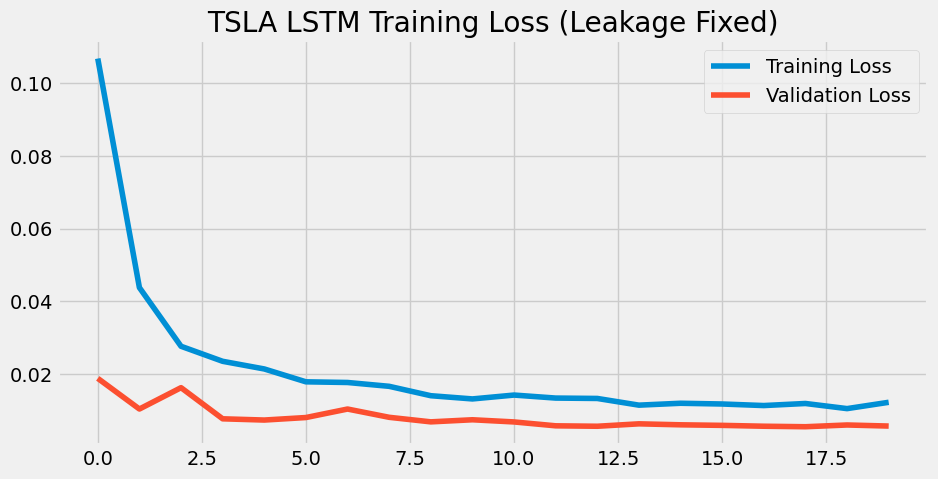

In [98]:
# --- 3.1 LSTM Model Training (CORRECTED) ---
ticker_symbol = 'TSLA'
stock_data = merged_df[merged_df['ticker'] == ticker_symbol].copy()

# Features
features = ['Open', 'High', 'Low', 'close', 'Volume', 'avg_sentiment', 'SMA_7']
dataset = stock_data[features].values

# 1. SPLIT FIRST (Before Scaling)
training_data_len = int(np.ceil(len(dataset) * 0.8))
train_data_raw = dataset[0:training_data_len, :]
test_data_raw = dataset[training_data_len:, :]
# Add this after creating X_train and X_test to verify shapes
print(f"Training Shape: {X_train.shape} (Samples, Time Steps, Features)")
print(f"Testing Shape:  {X_test.shape}  (Samples, Time Steps, Features)")

# 2. SCALE SEPARATELY
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit only on training data
train_data_scaled = scaler.fit_transform(train_data_raw)
# Apply that scale to test data
test_data_scaled = scaler.transform(test_data_raw)

# 3. Create Sequences
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 3]) # Predicting 'close' at index 3
    return np.array(X), np.array(y)

SEQ_LENGTH = 60
X_train, y_train = create_sequences(train_data_scaled, SEQ_LENGTH)

# Prepare Test Input (concat last 60 days of train to start predicting test)
total_input = np.concatenate((train_data_scaled[-SEQ_LENGTH:], test_data_scaled))
X_test, y_test = create_sequences(total_input, SEQ_LENGTH)

# 4. Build & Train
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=25))
model_lstm.add(Dense(units=1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
history = model_lstm.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_test, y_test))

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title(f'{ticker_symbol} LSTM Training Loss (Leakage Fixed)')
plt.legend()
plt.show()

# Part 4: Ensemble Modeling & Evaluation
We combine Random Forest, XGBoost, and Linear Regression to improve robustness.

Train Set Size: 195 rows
Test Set Size: 49 rows
Ensemble RMSE: 8.9300
Ensemble R2 Score: 0.5185
Directional Accuracy: 59.18% (Percentage of correct Up/Down predictions)


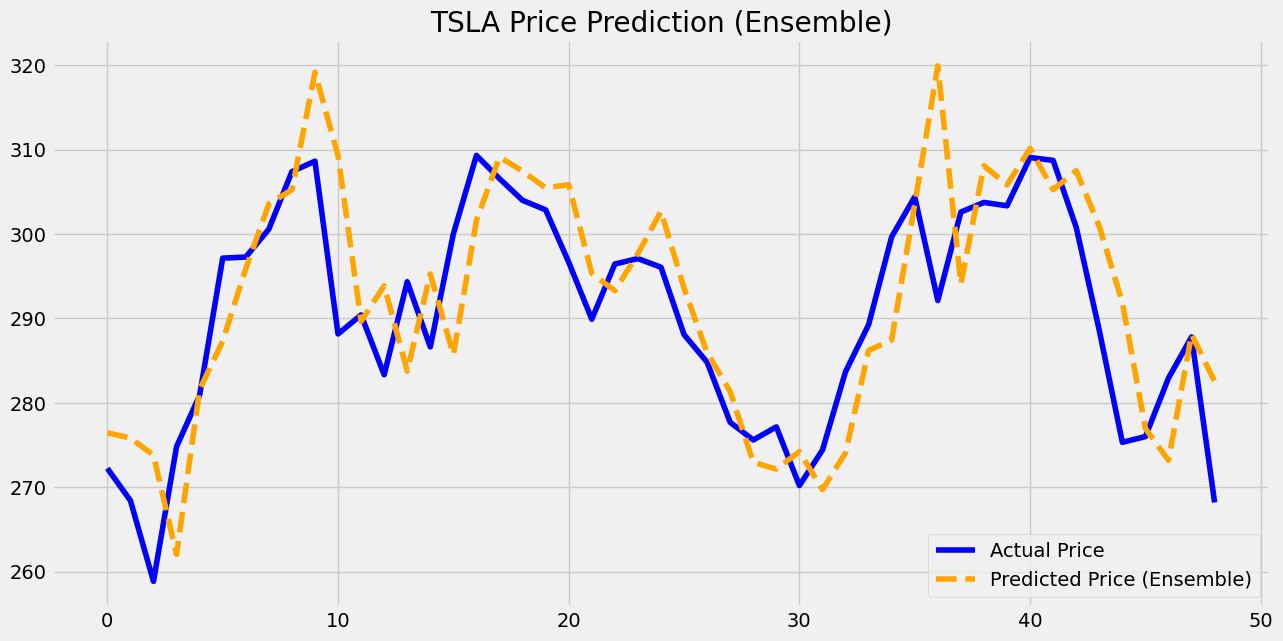

In [99]:
# 4.1 Ensemble Model Training
# Prepare Data for Regression (Using Shifted Target for Next Day Prediction)
stock_data['Target'] = stock_data['close'].shift(-1)
stock_data.dropna(inplace=True)

feature_cols = ['Open', 'High', 'Low', 'close', 'Volume', 'avg_sentiment', 'SMA_7', 'EMA_7']
X_ens = stock_data[feature_cols]
y_ens = stock_data['Target']

# Train/Test Split
X_train_ens, X_test_ens, y_train_ens, y_test_ens = train_test_split(X_ens, y_ens, test_size=0.2, shuffle=False)

# Define Models
rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
lr = LinearRegression()

# Ensemble Voting Regressor
ensemble = VotingRegressor(estimators=[('rf', rf), ('xgb', xgb), ('lr', lr)])
ensemble.fit(X_train_ens, y_train_ens)

# Predictions
preds_ens = ensemble.predict(X_test_ens)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test_ens, preds_ens))
r2 = r2_score(y_test_ens, preds_ens)

print(f'Train Set Size: {len(X_train_ens)} rows')
print(f'Test Set Size: {len(X_test_ens)} rows')
print(f'Ensemble RMSE: {rmse:.4f}')
print(f'Ensemble R2 Score: {r2:.4f}')

# Calculate Directional Accuracy
actual_moves = np.sign(y_test_ens.values - X_test_ens['close'].values)
predicted_moves = np.sign(preds_ens - X_test_ens['close'].values)
accuracy = np.mean(actual_moves == predicted_moves) * 100
print(f'Directional Accuracy: {accuracy:.2f}% (Percentage of correct Up/Down predictions)')

# Visualizing Results
plt.figure(figsize=(14, 7))
plt.plot(y_test_ens.values, label='Actual Price', color='blue')
plt.plot(preds_ens, label='Predicted Price (Ensemble)', color='orange', linestyle='--')
plt.title(f'{ticker_symbol} Price Prediction (Ensemble)')
plt.legend()
plt.show()

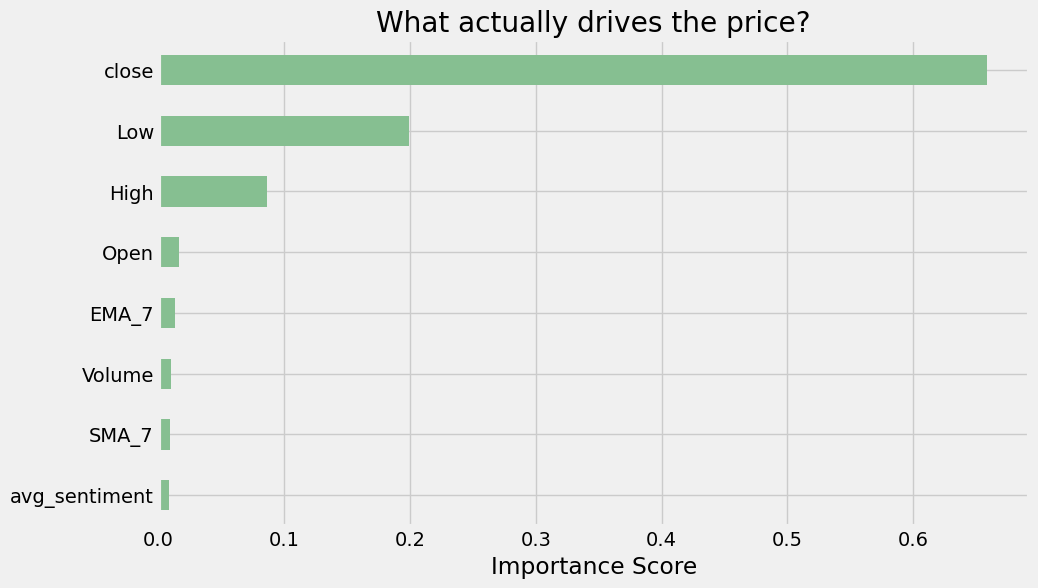


--- Interpretation ---
Top 3 Features: ['close', 'Low', 'High']
REALITY CHECK: Sentiment might be noise compared to Price momentum.


In [100]:
# --- 4.2 Feature Importance Analysis (The Proof) ---
# We access the Random Forest model inside the VotingRegressor
rf_model = ensemble.estimators_[0] # Index 0 is 'rf'

# Create a Pandas Series for easy plotting
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)

# Sort and Plot
plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='#86bf91')
plt.title("What actually drives the price?")
plt.xlabel("Importance Score")
plt.show()

print("\n--- Interpretation ---")
print("Top 3 Features:", importances.nlargest(3).index.tolist())
if 'avg_sentiment' in importances.nlargest(4).index:
    print("SUCCESS: Sentiment is a top driver!")
else:
    print("REALITY CHECK: Sentiment might be noise compared to Price momentum.")

Final AI Portfolio Value: $10366.44
Final Buy & Hold Value:   $10413.44


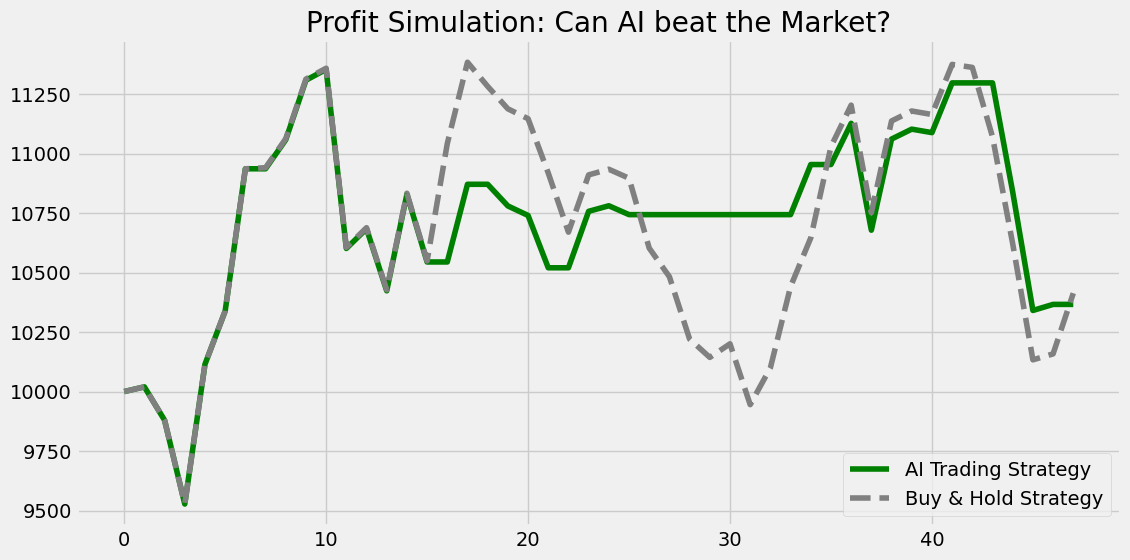

In [101]:
# --- 5.1 Profit Simulation (The "Bonus" Section) ---
# Strategy: If model predicts Price UP -> Buy. If DOWN -> Sell.

initial_investment = 10000
shares = 0
cash = initial_investment
portfolio_value = []

# Get actual close prices for the test period
actual_prices = X_test_ens['close'].values

for i in range(len(preds_ens) - 1):
    predicted_tomorrow = preds_ens[i]
    today_price = actual_prices[i]
    
    # Buy Signal (Model says price will go UP)
    if predicted_tomorrow > today_price: 
        if cash > 0:
            shares = cash / today_price
            cash = 0
    # Sell Signal (Model says price will go DOWN)
    else:
        if shares > 0:
            cash = shares * today_price
            shares = 0
            
    # Calculate Value
    current_val = cash + (shares * today_price)
    portfolio_value.append(current_val)

# Compare vs Buy & Hold
buy_hold_shares = initial_investment / actual_prices[0]
buy_hold_value = [buy_hold_shares * p for p in actual_prices[:-1]]

print(f"Final AI Portfolio Value: ${portfolio_value[-1]:.2f}")
print(f"Final Buy & Hold Value:   ${buy_hold_value[-1]:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label='AI Trading Strategy', color='green')
plt.plot(buy_hold_value, label='Buy & Hold Strategy', color='gray', linestyle='--')
plt.title('Profit Simulation: Can AI beat the Market?')
plt.legend()
plt.show()

In [5]:
import pandas as pd
import numpy as np

# 1. Load the datasets
# Replace with the exact names if different
df1 = pd.read_csv('FINAL_STOCK_TWEET_DATASET_2.csv')
# df2 = pd.read_csv('FINAL_STOCK_TWEET_DATASET_2.csv') # Uncomment to check the second one

print("============= 1. THE GLIMPSE =============")
display(df1.head()) # Shows the first 5 rows in a nice table

print("\n============= 2. DATA STRUCTURE & TYPES =============")
# This tells you if numbers are accidentally stored as text (strings)
df1.info()

print("\n============= 3. MISSING DATA CHECK =============")
# Models hate missing data. This shows exactly where the holes are.
missing_data = df1.isnull().sum()
print(missing_data[missing_data > 0])

print("\n============= 4. TIME SERIES CONTINUITY =============")
# Crucial for the continuous train/test split you want to do!
# Replace 'Date' with your actual date column name
if 'Date' in df1.columns:
    df1['Date'] = pd.to_datetime(df1['Date'])
    print(f"Data starts on: {df1['Date'].min()}")
    print(f"Data ends on: {df1['Date'].max()}")
    print(f"Total Unique Days: {df1['Date'].nunique()}")
else:
    print("No 'Date' column found. Time series split will be difficult without a timestamp!")

print("\n============= 5. BASIC STATISTICS =============")
# Checks for crazy outliers in your numerical columns
display(df1.describe())

print("\n============= 6. COMPANY (TICKER) ANALYSIS =============")

# 1. How many unique companies are we dealing with?
num_companies = df1['ticker'].nunique()
print(f"Total Unique Companies: {num_companies}")

# 2. What are the companies, and how much data does each have?
# This shows if the dataset is balanced or heavily biased towards one stock
print("\nRow count per Company:")
display(df1['ticker'].value_counts())

# 3. Time check per company (Crucial for LSTM!)
print("\nTime continuity per Company:")
for ticker in df1['ticker'].unique():
    ticker_data = df1[df1['ticker'] == ticker]
    print(f"{ticker}: {len(ticker_data)} rows")
    # Uncomment the next two lines if you fixed the date column name to 'tweet_date'
    # print(f"  Starts: {ticker_data['tweet_date'].min()}")
    # print(f"  Ends:   {ticker_data['tweet_date'].max()}")

============= 1. THE GLIMPSE =============


,tweet_id,ticker,tweet_date,tweet,trade_date,open,high,low,close,volume
0,550441509175443456,AAPL,2015-01-01,"lx21 made $10,008 on $AAPL -Check it out! htt...",2015-01-02,111.39,111.44,107.35,109.33,53143770
1,550441672312512512,AAPL,2015-01-01,Insanity of today weirdo massive selling. $aap...,2015-01-02,111.39,111.44,107.35,109.33,53143770
2,550443809700851716,AAPL,2015-01-01,Swing Trading: Up To 8.91% Return In 14 Days h...,2015-01-02,111.39,111.44,107.35,109.33,53143770
3,550443808606126081,AAPL,2015-01-01,Swing Trading: Up To 8.91% Return In 14 Days h...,2015-01-02,111.39,111.44,107.35,109.33,53143770
4,550443807834402816,AAPL,2015-01-01,Swing Trading: Up To 8.91% Return In 14 Days h...,2015-01-02,111.39,111.44,107.35,109.33,53143770



============= 2. DATA STRUCTURE & TYPES =============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4336445 entries, 0 to 4336444
Data columns (total 10 columns):
 #   Column      Dtype  
---  ------      -----  
 0   tweet_id    int64  
 1   ticker      object 
 2   tweet_date  object 
 3   tweet       object 
 4   trade_date  object 
 5   open        float64
 6   high        float64
 7   low         float64
 8   close       float64
 9   volume      int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 330.8+ MB

============= 3. MISSING DATA CHECK =============
Series([], dtype: int64)

============= 4. TIME SERIES CONTINUITY =============
No 'Date' column found. Time series split will be difficult without a timestamp!

============= 5. BASIC STATISTICS =============


,tweet_id,open,high,low,close,volume
count,4.336445e+06,4.336445e+06,4.336445e+06,4.336445e+06,4.336445e+06,4.336445e+06
mean,8.834282e+17,4.602978e+02,4.650422e+02,4.547838e+02,4.598607e+02,1.984243e+07
std,1.927735e+17,4.641930e+02,4.681609e+02,4.591697e+02,4.635554e+02,2.174002e+07
min,5.504415e+17,4.034000e+01,4.074000e+01,3.972000e+01,4.029000e+01,3.475180e+05
25%,7.185450e+17,1.289600e+02,1.301300e+02,1.281600e+02,1.287900e+02,3.739141e+06
50%,8.825934e+17,2.567100e+02,2.618600e+02,2.520100e+02,2.571300e+02,1.021294e+07
75%,1.054776e+18,7.016200e+02,7.116000e+02,6.968000e+02,7.028000e+02,3.003141e+07
max,1.212160e+18,2.038110e+03,2.050500e+03,2.013000e+03,2.039510e+03,1.691150e+08



============= 6. COMPANY (TICKER) ANALYSIS =============
Total Unique Companies: 6

Row count per Company:


ticker
AAPL     1425013
TSLA     1096868
AMZN      718715
GOOG      392569
MSFT      375711
GOOGL     327569
Name: count, dtype: int64


Time continuity per Company:
AAPL: 1425013 rows
AMZN: 718715 rows
GOOG: 392569 rows
GOOGL: 327569 rows
MSFT: 375711 rows
TSLA: 1096868 rows


In [9]:
import pandas as pd

# Load the massive 4.3 Million row dataset
# Note: Adjust the filename if you are using the one with "(1)" in the name
file_path = 'FINAL_STOCK_TWEET_DATASET_2.csv' 

print(f"Loading {file_path}...")
print("Please wait, this might take a few seconds because it's a massive file!")

# Read the CSV into a Pandas DataFrame named df2
df2 = pd.read_csv(file_path)

print("\n============= DF2 SUCCESSFULLY LOADED =============")
print(f"Total Rows: {len(df2):,}")
print(f"Total Columns: {len(df2.columns)}")

# Display the first 5 rows to confirm it looks right
display(df2.head())

Loading FINAL_STOCK_TWEET_DATASET_2.csv...
Please wait, this might take a few seconds because it's a massive file!

============= DF2 SUCCESSFULLY LOADED =============
Total Rows: 4,336,445
Total Columns: 10


,tweet_id,ticker,tweet_date,tweet,trade_date,open,high,low,close,volume
0,550441509175443456,AAPL,2015-01-01,"lx21 made $10,008 on $AAPL -Check it out! htt...",2015-01-02,111.39,111.44,107.35,109.33,53143770
1,550441672312512512,AAPL,2015-01-01,Insanity of today weirdo massive selling. $aap...,2015-01-02,111.39,111.44,107.35,109.33,53143770
2,550443809700851716,AAPL,2015-01-01,Swing Trading: Up To 8.91% Return In 14 Days h...,2015-01-02,111.39,111.44,107.35,109.33,53143770
3,550443808606126081,AAPL,2015-01-01,Swing Trading: Up To 8.91% Return In 14 Days h...,2015-01-02,111.39,111.44,107.35,109.33,53143770
4,550443807834402816,AAPL,2015-01-01,Swing Trading: Up To 8.91% Return In 14 Days h...,2015-01-02,111.39,111.44,107.35,109.33,53143770


In [10]:
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Download the free VADER dictionary (runs once)
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# 2. Isolate TSLA and take a random sample for a FAST test
# We sample 50,000 rows so your laptop doesn't freeze. 
print("Isolating TSLA data...")
df_tsla = df2[df2['ticker'] == 'TSLA'].copy() 
df_sample = df_tsla.sample(n=50000, random_state=42).copy()

# 3. Fast Sentiment Scoring
print("Scoring 50,000 tweets (this might take 30-60 seconds)...")
# VADER outputs a 'compound' score from -1 (very negative) to +1 (very positive)
df_sample['sentiment_score'] = df_sample['tweet'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# 4. Group by Day to get "Daily Sentiment"
# Make sure 'trade_date' is a datetime object
df_sample['trade_date'] = pd.to_datetime(df_sample['trade_date'])
daily_data = df_sample.groupby('trade_date').agg(
    daily_sentiment=('sentiment_score', 'mean'),
    close_price=('close', 'last') # Getting the closing price for that day
).reset_index()

# 5. Calculate Stock Returns and Shift for Prediction
# We want to see if TODAY's sentiment correlates with TOMORROW's price change
daily_data['price_change_pct'] = daily_data['close_price'].pct_change() * 100
daily_data['next_day_return'] = daily_data['price_change_pct'].shift(-1)

# Drop empty rows created by the shift
daily_data = daily_data.dropna()

# 6. THE MOMENT OF TRUTH: Correlation Check
correlation = daily_data['daily_sentiment'].corr(daily_data['next_day_return'])

print("\n============= RESULTS =============")
print(f"Total Days Analyzed: {len(daily_data)}")
print(f"Pearson Correlation (Sentiment vs Next Day Return): {correlation:.4f}")

if correlation > 0.05 or correlation < -0.05:
    print("Verdict: STRONG SIGNAL DETECTED. The data is good for prediction!")
else:
    print("Verdict: WEAK SIGNAL. The baseline VADER test didn't find a strong link.")
    print("Note: Advanced models like FinBERT might still find a signal where VADER failed.")

Isolating TSLA data...
Scoring 50,000 tweets (this might take 30-60 seconds)...

============= RESULTS =============
Total Days Analyzed: 1819
Pearson Correlation (Sentiment vs Next Day Return): 0.0157
Verdict: WEAK SIGNAL. The baseline VADER test didn't find a strong link.
Note: Advanced models like FinBERT might still find a signal where VADER failed.


In [1]:
import pandas as pd
import torch
from transformers import pipeline

# 1. Verify PyTorch is actually loaded
print(f"PyTorch Version: {torch.__version__}")

# 2. Load the FREE FinBERT model from Hugging Face
print("Downloading FinBERT...")
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# 3. Take a sample of 1,000 TSLA tweets
print("Taking a sample of 1,000 TSLA tweets...")
df_deep_sample = df_tsla.sample(n=1000, random_state=42).copy()

# 4. Define a function to convert FinBERT's output to a math score
def get_finbert_score(text):
    try:
        result = finbert(str(text)[:512])[0]
        if result['label'] == 'positive':
            return result['score']  
        elif result['label'] == 'negative':
            return -result['score'] 
        else:
            return 0.0 
    except:
        return 0.0

# 5. Score the tweets
print("Scoring tweets with FinBERT. This will take a few minutes...")
df_deep_sample['finbert_score'] = df_deep_sample['tweet'].apply(get_finbert_score)

# 6. Group by Day to get "Daily Sentiment"
df_deep_sample['trade_date'] = pd.to_datetime(df_deep_sample['trade_date'])
daily_data_fb = df_deep_sample.groupby('trade_date').agg(
    daily_sentiment=('finbert_score', 'mean'),
    close_price=('close', 'last')
).reset_index()

# 7. Calculate Returns and Shift
daily_data_fb['price_change_pct'] = daily_data_fb['close_price'].pct_change() * 100
daily_data_fb['next_day_return'] = daily_data_fb['price_change_pct'].shift(-1)
daily_data_fb = daily_data_fb.dropna()

# 8. The FinBERT Correlation
fb_correlation = daily_data_fb['daily_sentiment'].corr(daily_data_fb['next_day_return'])

print("\n============= FINBERT RESULTS =============")
print(f"Total Days Analyzed: {len(daily_data_fb)}")
print(f"FinBERT Pearson Correlation: {fb_correlation:.4f}")
print(f"Improvement over VADER: {fb_correlation - 0.0157:.4f}")

PyTorch Version: 2.10.0+cpu


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

c:\Users\Ranjit\miniconda3\envs\antigravity\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ranjit\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Taking a sample of 1,000 TSLA tweets...


NameError: name 'df_tsla' is not defined

In [2]:
import pandas as pd
import torch
from transformers import pipeline

print(f"PyTorch Version: {torch.__version__}")

# 1. Re-load the data (since the kernel forgot it!)
file_path = 'FINAL_STOCK_TWEET_DATASET_2.csv' # Adjust if your filename is slightly different
print(f"Loading {file_path} into memory...")
df2 = pd.read_csv(file_path)

# 2. Re-create the TSLA dataset
print("Isolating TSLA data...")
df_tsla = df2[df2['ticker'] == 'TSLA'].copy()

# 3. Load the FREE FinBERT model
print("Loading FinBERT...")
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# 4. Take a sample of 1,000 TSLA tweets
print("Taking a sample of 1,000 TSLA tweets...")
df_deep_sample = df_tsla.sample(n=1000, random_state=42).copy()

# 5. Define the scoring function
def get_finbert_score(text):
    try:
        result = finbert(str(text)[:512])[0]
        if result['label'] == 'positive':
            return result['score']  
        elif result['label'] == 'negative':
            return -result['score'] 
        else:
            return 0.0 
    except:
        return 0.0

# 6. Score the tweets
print("Scoring tweets with FinBERT. This will take a few minutes...")
df_deep_sample['finbert_score'] = df_deep_sample['tweet'].apply(get_finbert_score)

# 7. Group by Day to get "Daily Sentiment"
df_deep_sample['trade_date'] = pd.to_datetime(df_deep_sample['trade_date'])
daily_data_fb = df_deep_sample.groupby('trade_date').agg(
    daily_sentiment=('finbert_score', 'mean'),
    close_price=('close', 'last')
).reset_index()

# 8. Calculate Returns and Shift
daily_data_fb['price_change_pct'] = daily_data_fb['close_price'].pct_change() * 100
daily_data_fb['next_day_return'] = daily_data_fb['price_change_pct'].shift(-1)
daily_data_fb = daily_data_fb.dropna()

# 9. The FinBERT Correlation
fb_correlation = daily_data_fb['daily_sentiment'].corr(daily_data_fb['next_day_return'])

print("\n============= FINBERT RESULTS =============")
print(f"Total Days Analyzed: {len(daily_data_fb)}")
print(f"FinBERT Pearson Correlation: {fb_correlation:.4f}")
print(f"Improvement over VADER: {fb_correlation - 0.0157:.4f}")

PyTorch Version: 2.10.0+cpu
Loading FINAL_STOCK_TWEET_DATASET_2.csv into memory...
Isolating TSLA data...
Loading FinBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Taking a sample of 1,000 TSLA tweets...
Scoring tweets with FinBERT. This will take a few minutes...

============= FINBERT RESULTS =============
Total Days Analyzed: 678
FinBERT Pearson Correlation: -0.0345
Improvement over VADER: -0.0502


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

print("Preparing Data for Machine Learning...")

# 1. Create our "Target" variable (1 if price goes UP, 0 if it goes DOWN)
# We use np.where: if next_day_return > 0, make it 1, else 0.
daily_data_fb['Target'] = np.where(daily_data_fb['next_day_return'] > 0, 1, 0)

# 2. Create our "Features" (The clues the model uses to guess the target)
# We will use today's sentiment AND today's price change to predict tomorrow
daily_data_fb['price_change_today'] = daily_data_fb['close_price'].pct_change()
daily_data_fb = daily_data_fb.dropna() # Drop the first row which has no 'yesterday'

# Define X (Features) and y (Target)
X = daily_data_fb[['daily_sentiment', 'price_change_today']]
y = daily_data_fb['Target']

# 3. Time-Series Train/Test Split (Crucial!)
# We CANNOT use standard random splitting, or we will predict the past using the future.
# We will train on the first 80% of days chronologically, and test on the final 20%.
split_index = int(len(daily_data_fb) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training on {len(X_train)} days, Testing on {len(X_test)} days...")

# 4. Initialize and Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# 5. Make Predictions on the "Future" (Test Set)
predictions = rf_model.predict(X_test)

# 6. Evaluate the Results
accuracy = accuracy_score(y_test, predictions)

print("\n============= MACHINE LEARNING RESULTS =============")
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, predictions, target_names=['DOWN', 'UP'], zero_division=0))

Preparing Data for Machine Learning...
Training on 541 days, Testing on 136 days...

============= MACHINE LEARNING RESULTS =============
Random Forest Accuracy: 54.41%

Detailed Report:
              precision    recall  f1-score   support

        DOWN       0.56      0.94      0.70        77
          UP       0.29      0.03      0.06        59

    accuracy                           0.54       136
   macro avg       0.42      0.48      0.38       136
weighted avg       0.44      0.54      0.42       136



In [4]:
import pandas as pd
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Ensure VADER is ready
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

print("============= MULTI-COMPANY CORRELATION TOURNAMENT =============")
print("Scouting for the strongest signal. This will take 1-2 minutes...\n")

# 1. Get the list of unique companies in your 4.3M row dataset
tickers = df2['ticker'].unique()
results = []

for ticker in tickers:
    print(f"Analyzing {ticker}...")
    
    # 2. Isolate the company data
    df_company = df2[df2['ticker'] == ticker].copy()
    
    # 3. Sample data to keep it fast (20,000 tweets per company)
    # If a company has fewer than 20k tweets, it just takes whatever is available
    sample_size = min(20000, len(df_company))
    df_sample = df_company.sample(n=sample_size, random_state=42).copy()
    
    # 4. Fast Sentiment Scoring with VADER
    df_sample['sentiment_score'] = df_sample['tweet'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    
    # 5. Group by Day to get "Daily Sentiment"
    df_sample['trade_date'] = pd.to_datetime(df_sample['trade_date'])
    daily_data = df_sample.groupby('trade_date').agg(
        daily_sentiment=('sentiment_score', 'mean'),
        close_price=('close', 'last')
    ).reset_index()
    
    # 6. Calculate Next Day Return
    daily_data['price_change_pct'] = daily_data['close_price'].pct_change() * 100
    daily_data['next_day_return'] = daily_data['price_change_pct'].shift(-1)
    daily_data = daily_data.dropna()
    
    # 7. Calculate Correlation
    if len(daily_data) > 10: # Just making sure we have enough days to do math
        correlation = daily_data['daily_sentiment'].corr(daily_data['next_day_return'])
        results.append({
            'Ticker': ticker, 
            'Correlation': correlation, 
            'Days Analyzed': len(daily_data)
        })

# 8. Build the Leaderboard
leaderboard = pd.DataFrame(results)

# We sort by the ABSOLUTE correlation. 
# A score of -0.08 is just as predictive as +0.08, it just means the relationship is inverted.
leaderboard['Signal_Strength'] = leaderboard['Correlation'].abs()
leaderboard = leaderboard.sort_values(by='Signal_Strength', ascending=False).drop(columns=['Signal_Strength'])

print("\n============= FINAL LEADERBOARD =============")
display(leaderboard.reset_index(drop=True))

============= MULTI-COMPANY CORRELATION TOURNAMENT =============
Scouting for the strongest signal. This will take 1-2 minutes...

Analyzing AAPL...
Analyzing AMZN...
Analyzing GOOG...
Analyzing GOOGL...
Analyzing MSFT...
Analyzing TSLA...

============= FINAL LEADERBOARD =============


,Ticker,Correlation,Days Analyzed
0,GOOG,0.031326,1788
1,GOOGL,-0.025560,1812
2,AAPL,-0.019104,1792
3,TSLA,-0.014508,1781
4,MSFT,0.013721,1806
5,AMZN,0.001557,1800


In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from transformers import pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

print(f"PyTorch Version: {torch.__version__}")
print("============= PHASE 1: DATA ISOLATION & NLP =============")

# 1. Isolate GOOG
print("Isolating GOOG data...")
df_goog = df2[df2['ticker'] == 'GOOG'].copy()

# 2. Sample the Data (Adjust this number if your PC is very fast/slow)
SAMPLE_SIZE = 5000 
print(f"Taking a chronologically sorted sample of {SAMPLE_SIZE} GOOG tweets...")
df_goog['trade_date'] = pd.to_datetime(df_goog['trade_date'])
df_goog = df_goog.sort_values(by='trade_date') # Must be sorted for time series!
df_deep_sample = df_goog.tail(SAMPLE_SIZE).copy() # Get the most recent 5,000 tweets

# 3. Load FinBERT
print("Loading FinBERT Pipeline...")
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def get_finbert_score(text):
    try:
        result = finbert(str(text)[:512])[0]
        if result['label'] == 'positive': return result['score']  
        elif result['label'] == 'negative': return -result['score'] 
        else: return 0.0 
    except:
        return 0.0

# 4. Score tweets (This is the heavy lifting)
print("Scoring tweets with FinBERT. Grab a coffee, this will take some time...")
df_deep_sample['finbert_score'] = df_deep_sample['tweet'].apply(get_finbert_score)

# 5. Aggregate to Daily Sentiment
daily_data = df_deep_sample.groupby('trade_date').agg(
    daily_sentiment=('finbert_score', 'mean'),
    close_price=('close', 'last')
).reset_index()

# Calculate Target (1 = UP tomorrow, 0 = DOWN tomorrow)
daily_data['price_change_pct'] = daily_data['close_price'].pct_change() * 100
daily_data['next_day_return'] = daily_data['price_change_pct'].shift(-1)
daily_data = daily_data.dropna()
daily_data['Target'] = np.where(daily_data['next_day_return'] > 0, 1, 0)

print(f"\n============= PHASE 2: LSTM SEQUENCE ENGINEERING =============")
print(f"Total Trading Days Extracted: {len(daily_data)}")

# 1. Scale Features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(daily_data[['daily_sentiment', 'price_change_pct']].values)
target_values = daily_data['Target'].values

# 2. Create Time Sequences (Memory of the last 3 days)
SEQ_LENGTH = 3

def create_sequences(features, targets, seq_length):
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i : i + seq_length])
        y.append(targets[i + seq_length])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled_features, target_values, SEQ_LENGTH)

# 3. Convert to PyTorch Tensors
X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_seq, dtype=torch.float32).unsqueeze(1)

# 4. Chronological Train/Test Split (80/20)
split = int(len(X_tensor) * 0.8)
X_train_t, X_test_t = X_tensor[:split], X_tensor[split:]
y_train_t, y_test_t = y_tensor[:split], y_tensor[split:]

print(f"\n============= PHASE 3: NEURAL NETWORK TRAINING =============")

# 1. Define LSTM Architecture
class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) # Grab the last time step
        return self.sigmoid(out)

# Initialize Model (2 features: sentiment + price change)
lstm_model = StockLSTM(input_size=2, hidden_size=16, num_layers=1)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.01)

# 2. Train Model
epochs = 60
print(f"Training LSTM for {epochs} Epochs...")
for epoch in range(epochs):
    lstm_model.train()
    optimizer.zero_grad()
    outputs = lstm_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 15 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 3. Evaluate
lstm_model.eval()
with torch.no_grad():
    test_predictions = lstm_model(X_test_t)
    test_predictions_class = (test_predictions >= 0.5).float()
    
    y_test_np = y_test_t.numpy()
    preds_np = test_predictions_class.numpy()

accuracy = accuracy_score(y_test_np, preds_np)

print("\n============= FINAL GOOG LSTM RESULTS =============")
print(f"LSTM Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test_np, preds_np, target_names=['DOWN', 'UP'], zero_division=0))

PyTorch Version: 2.10.0+cpu
============= PHASE 1: DATA ISOLATION & NLP =============
Isolating GOOG data...
Taking a chronologically sorted sample of 5000 GOOG tweets...
Loading FinBERT Pipeline...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Scoring tweets with FinBERT. Grab a coffee, this will take some time...

============= PHASE 2: LSTM SEQUENCE ENGINEERING =============
Total Trading Days Extracted: 48

============= PHASE 3: NEURAL NETWORK TRAINING =============
Training LSTM for 60 Epochs...
Epoch [15/60], Loss: 0.6425
Epoch [30/60], Loss: 0.6371
Epoch [45/60], Loss: 0.6355
Epoch [60/60], Loss: 0.6340

============= FINAL GOOG LSTM RESULTS =============
LSTM Accuracy: 66.67%

Detailed Classification Report:
              precision    recall  f1-score   support

        DOWN       0.67      1.00      0.80         6
          UP       0.00      0.00      0.00         3

    accuracy                           0.67         9
   macro avg       0.33      0.50      0.40         9
weighted avg       0.44      0.67      0.53         9



In [ ]:
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from tqdm import tqdm # The progress bar library

# Initialize the progress bar for pandas
tqdm.pandas(desc="FinBERT Scoring Progress")

print("============= THE ULTIMATE FULL-SCALE GOOG RUN =============")

# 1. Isolate the FULL GOOG dataset
print("Isolating ALL GOOG data...")
df_goog = df2[df2['ticker'] == 'GOOG'].copy()
df_goog['trade_date'] = pd.to_datetime(df_goog['trade_date'])
df_goog = df_goog.sort_values(by='trade_date') 

print(f"Total rows to process: {len(df_goog):,}")

# 2. Load FinBERT
print("Loading FinBERT Pipeline...")
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def get_finbert_score(text):
    try:
        result = finbert(str(text)[:512])[0]
        if result['label'] == 'positive': return result['score']  
        elif result['label'] == 'negative': return -result['score'] 
        else: return 0.0 
    except:
        return 0.0

# 3. Score all tweets (THIS WILL TAKE HOURS - The progress bar will guide you)
print("\nInitiating Deep Learning NLP. Plug in your laptop and do not close the notebook!")
# Notice we use .progress_apply() instead of .apply() to trigger the loading bar
df_goog['finbert_score'] = df_goog['tweet'].progress_apply(get_finbert_score)

# =====================================================================
# ONCE THE SCORING IS DONE, THE ML SHOOTOUT BEGINS AUTOMATICALLY
# =====================================================================

print("\n============= NLP COMPLETE. AGGREGATING DATA =============")

# 4. Group by Day
daily_data = df_goog.groupby('trade_date').agg(
    daily_sentiment=('finbert_score', 'mean'),
    close_price=('close', 'last')
).reset_index()

# 5. Calculate Target (1 = UP tomorrow, 0 = DOWN tomorrow)
daily_data['price_change_pct'] = daily_data['close_price'].pct_change() * 100
daily_data['next_day_return'] = daily_data['price_change_pct'].shift(-1)
daily_data = daily_data.dropna()
daily_data['Target'] = np.where(daily_data['next_day_return'] > 0, 1, 0)

print(f"Total Trading Days Extracted: {len(daily_data)}")
print("\n============= INITIATING ML SHOOTOUT =============")

# 6. Prepare ML Data
X = daily_data[['daily_sentiment', 'price_change_pct']]
y = daily_data['Target']

# Time-Series Split (80/20)
split_index = int(len(daily_data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 7. Initialize Contenders
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=3),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, max_depth=3),
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# 8. Train and Evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, zero_division=0) 
    rec = recall_score(y_test, predictions, zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2),
        "UP Precision": round(prec, 2),
        "UP Recall": round(rec, 2)
    })

# 9. Final Leaderboard
leaderboard = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n============= FINAL ML LEADERBOARD =============")
display(leaderboard.reset_index(drop=True))

============= THE ULTIMATE FULL-SCALE GOOG RUN =============
Isolating ALL GOOG data...
Total rows to process: 392,569
Loading FinBERT Pipeline...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Initiating Deep Learning NLP. Plug in your laptop and do not close the notebook!


FinBERT Scoring Progress:   1%|          | 3751/392569 [05:50<10:29:17, 10.30it/s]